In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage
from pydantic import BaseModel
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai.embeddings import OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
import re

In [3]:
load_dotenv(
)

True

In [4]:
model = ChatOpenAI(
    model='gpt-4o-mini',
    #api_key=os.getenv("OPENAI_API_KEY")
)

In [5]:
#pdfloader = PyPDFLoader('intor_to_ml.pdf')
docs= PyPDFLoader('book1.pdf').load()+ PyPDFLoader('book2.pdf').load()+ PyPDFLoader('book3.pdf').load()
# doc

In [6]:
#-------------- Text Splitter---------------------------------------
splitter = RecursiveCharacterTextSplitter(chunk_size= 1000, chunk_overlap= 200)
chunks= splitter.split_documents(docs)
len(chunks)

5918

In [7]:
embedding = OpenAIEmbeddings(model='text-embedding-3-small')
vector_store= FAISS.from_documents(chunks, embedding)
vector_store

In [8]:
retriever= vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [9]:
class CRAGState(TypedDict):
    question: str
    answer: str
    docs:list[str]
    strips: list[str]
    verdict: str
    kept_strips: list[str]
    refined_context: str

In [10]:
def retrieve(state: CRAGState):
    q= state['question']
    result = retriever.invoke(q)
    
    return{'docs': result}


In [11]:
prompt= ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know"),
        ("human", "Question:{question}\n Context:{context}")
    ]
)

In [12]:
def decompose_to_sentences(text: str) -> list[str]:
    text= re.sub(r"\s"," ",text).strip()
    sentences=  re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sentences if len(s)>20]

In [13]:
class keepOrDrop(BaseModel):
    keep: bool

In [14]:
filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

In [15]:
# filter 
filter_prompt_chain= filter_prompt | model.with_structured_output(keepOrDrop)

In [16]:
# Refining
def refine(state: CRAGState):
    q= state['question']
    context= "\n\n".join(d.page_content for d in state['docs']) # context for getting the strips
    strips = decompose_to_sentences(context)

    keep_strips: list[str]= []
    for strip in strips:
        if filter_prompt_chain.invoke({'question': q, 'sentence': strip}).keep:
            keep_strips.append(strip)
    
    refined_context= '\n'.join(keep_strips).strip()
    return{
        'strips': strips, 
        'kept_strips': keep_strips,
        'refined_context': refined_context
    }



In [17]:
def generate(state: CRAGState):
    context = "\n\n".join(d.page_content for d in state['docs'])
    q= state['question']
    out= (prompt | model).invoke({'question': q, 'context': context})

    return {'answer': out.content}
    

In [ ]:
def evaluate(state: CRAGState):
    return{'answer':'fail'}

In [23]:
def route_after_eval(state: CRAGState) -> str:
    if(state['verdict']) == 'incorrect':
        return 'websearch'
    
    elif(state['verdict']) == 'correct':
        return 'refine'
    
    else:
       return 'ambiguous' 
    




In [26]:
def ambiguous():
    return{'answer':'ambiguous'}

In [27]:
def fail():
    return{'answer':'fail'}

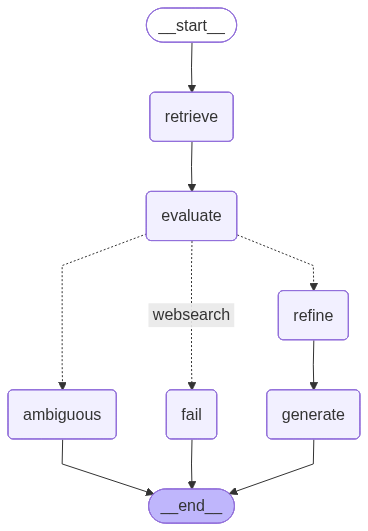

In [25]:
graph= StateGraph(CRAGState)
graph.add_node('retrieve', retrieve)
graph.add_node('generate', generate)
graph.add_node('evaluate', evaluate)
graph.add_node('refine', refine)
graph.add_node('ambiguous', ambiguous)
graph.add_node('fail', fail)

graph.add_edge(START, 'retrieve')
graph.add_edge('retrieve', 'evaluate')

graph.add_conditional_edges('evaluate', route_after_eval,
                            {'refine': 'refine', 'websearch': 'fail', 'ambiguous': 'ambiguous'  }
                            )
graph.add_edge('refine', 'generate')
graph.add_edge('generate', END)

workflow= graph.compile()

workflow


In [20]:
res = workflow.invoke({
    "question": "Explain the bias-variance tradeoff",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
        })
print(res["answer"])

InvalidUpdateError: Expected dict, got 
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE